# Lab 1 — Exploratory Data Analysis of Malware Features

Dataset: `dataset_malwares.csv` (19,611 samples, 79 columns). Target: `Malware` (0 = benign, 1 = malware).

## Setup & Load

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_malwares.csv")
X = df.drop(columns=["Name", "Malware"])
y = df["Malware"]
print("Loaded:", df.shape)

Loaded: (19611, 79)


## Task 1 — Dataset Profiling

In [13]:
print("Shape (samples, columns):", df.shape)
print("\nColumn dtype counts:\n", df.dtypes.value_counts())
print("\nNon-numeric columns:", [c for c in df.columns if df[c].dtype == object])
df.head()

Shape (samples, columns): (19611, 79)

Column dtype counts:
 int64      77
str         1
float64     1
Name: count, dtype: int64

Non-numeric columns: []


,Name,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
0,VirusShare_a878ba26000edaac5c98eff4432723b3,23117,144,3,0,4,0,65535,0,184,...,3758096608,0,7,152,0,0,54440,77824,73728,0
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0,23117,144,3,0,4,0,65535,0,184,...,3791650880,0,16,311,0,0,262276,294912,0,346112
2,VirusShare_ef84cdeba22be72a69b198213dada81a,23117,144,3,0,4,0,65535,0,184,...,3221225536,0,6,176,0,0,36864,40960,0,0
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e,23117,144,3,0,4,0,65535,0,184,...,3224371328,0,8,155,0,0,356352,1003520,0,14109472
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb,23117,144,3,0,4,0,65535,0,184,...,3227516992,0,2,43,0,0,61440,73728,0,90624


In [14]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
e_magic,19611.0,23117.000000,0.000000,23117.0,23117.0,23117.0,23117.0,23117.0
e_cblp,19611.0,178.615726,987.200729,0.0,144.0,144.0,144.0,59448.0
e_cp,19611.0,71.660752,1445.192977,0.0,3.0,3.0,3.0,63200.0
e_crlc,19611.0,49.146958,1212.201919,0.0,0.0,0.0,0.0,64613.0
e_cparhdr,19611.0,37.370710,864.515405,0.0,4.0,4.0,4.0,43690.0
e_minalloc,19611.0,37.032635,915.833139,0.0,0.0,0.0,0.0,43690.0
e_maxalloc,19611.0,64178.739687,9110.755873,0.0,65535.0,65535.0,65535.0,65535.0
e_ss,19611.0,10.418490,637.116265,0.0,0.0,0.0,0.0,61436.0
e_sp,19611.0,226.465300,1249.680330,0.0,184.0,184.0,184.0,65464.0
e_csum,19611.0,29.689103,1015.303419,0.0,0.0,0.0,0.0,63262.0


## Task 2 — Data Quality

In [15]:
missing = df.isnull().sum()
print("Columns with missing values:\n", missing[missing > 0] if (missing > 0).any() else "None")
print("\nDuplicate rows:", df.duplicated().sum())

constant_features = [c for c in X.columns if X[c].nunique() <= 1]
print("\nConstant features (nunique <= 1):\n", constant_features)

Columns with missing values:
 None

Duplicate rows: 0

Constant features (nunique <= 1):
 ['e_magic', 'SectionMaxEntropy', 'SectionMaxRawsize', 'SectionMaxVirtualsize', 'SectionMinPhysical', 'SectionMinVirtual', 'SectionMinPointerData', 'SectionMainChar']


## Task 3 — Target Distribution

Malware
1    14599
0     5012
Name: count, dtype: int64
Malware
1    0.7444
0    0.2556
Name: proportion, dtype: float64


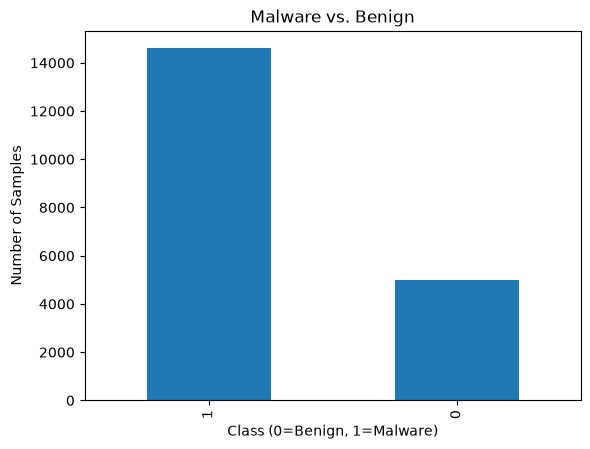

In [16]:
print(df["Malware"].value_counts())
print(df["Malware"].value_counts(normalize=True).round(4))

df["Malware"].value_counts().plot(kind="bar")
plt.xlabel("Class (0=Benign, 1=Malware)"); plt.ylabel("Number of Samples")
plt.title("Malware vs. Benign"); plt.show()

## Task 4 — Univariate Analysis

Features analysed: ['SizeOfCode', 'SizeOfImage', 'NumberOfSections', 'SizeOfHeaders', 'SizeOfInitializedData']


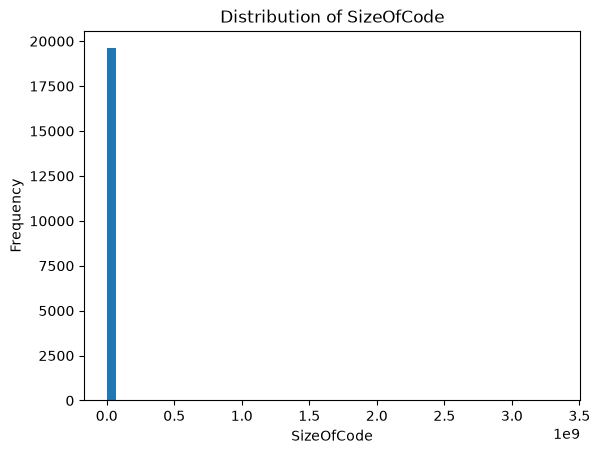

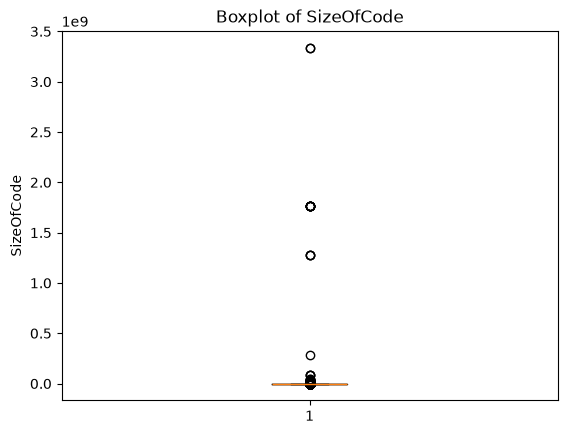


Skewness (|skew|), top 10:
SizeOfUninitializedData        139.8
SectionMaxVirtual              111.6
ImageDirectoryEntryResource     99.0
NumberOfRvaAndSizes             98.6
ImageDirectoryEntryExport       97.4
ImageDirectoryEntrySecurity     89.6
ImageDirectoryEntryImport       87.8
e_ss                            82.0
SizeOfStackCommit               73.4
MinorSubsystemVersion           70.0


In [17]:
features = [f for f in ["SizeOfCode", "SizeOfImage", "NumberOfSections",
                        "SizeOfHeaders", "SizeOfInitializedData"] if f in X.columns]
print("Features analysed:", features)

f = "SizeOfCode"
plt.hist(X[f], bins=50); plt.xlabel(f); plt.ylabel("Frequency")
plt.title(f"Distribution of {f}"); plt.show()

plt.boxplot(X[f].dropna()); plt.ylabel(f)
plt.title(f"Boxplot of {f}"); plt.show()

print("\nSkewness (|skew|), top 10:")
print(X[[c for c in X if c not in constant_features]].skew(numeric_only=True).abs()
      .sort_values(ascending=False).head(10).round(1).to_string())

## Task 5 — Malware vs Benign

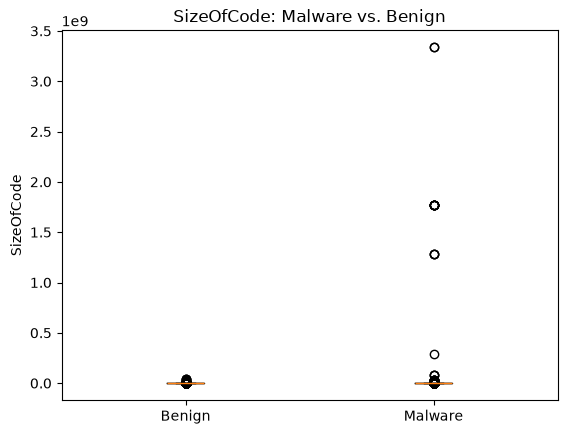

Top 10 features by absolute mean difference:


,Benign_Mean,Malware_Mean,Absolute_Difference
ImageBase,1.153568e+11,2.132334e+09,1.132245e+11
SectionMaxChar,2.770289e+09,3.298671e+09,5.283817e+08
TimeDateStamp,1.399571e+09,1.244201e+09,1.553703e+08
CheckSum,1.324230e+06,1.546858e+08,1.533616e+08
SectionMaxPointerData,6.819195e+05,3.103449e+07,3.035257e+07
AddressOfEntryPoint,1.771911e+05,1.073658e+07,1.055939e+07
NumberOfSymbols,1.841201e+01,9.553220e+06,9.553202e+06
PointerToSymbolTable,4.074650e+03,9.231503e+06,9.227428e+06
LoaderFlags,0.000000e+00,2.001147e+06,2.001147e+06
SizeOfInitializedData,4.355303e+05,2.400375e+06,1.964845e+06


In [18]:
malware = df[df["Malware"] == 1]
benign  = df[df["Malware"] == 0]

f = "SizeOfCode"
plt.boxplot([benign[f].dropna(), malware[f].dropna()])
plt.xticks([1, 2], ["Benign", "Malware"])
plt.ylabel(f); plt.title(f"{f}: Malware vs. Benign"); plt.show()

comparison = pd.DataFrame({
    "Benign_Mean": benign[X.columns].mean(),
    "Malware_Mean": malware[X.columns].mean()})
comparison["Absolute_Difference"] = (comparison["Malware_Mean"] - comparison["Benign_Mean"]).abs()
print("Top 10 features by absolute mean difference:")
comparison.sort_values("Absolute_Difference", ascending=False).head(10)

## Task 6 — Feature Correlation

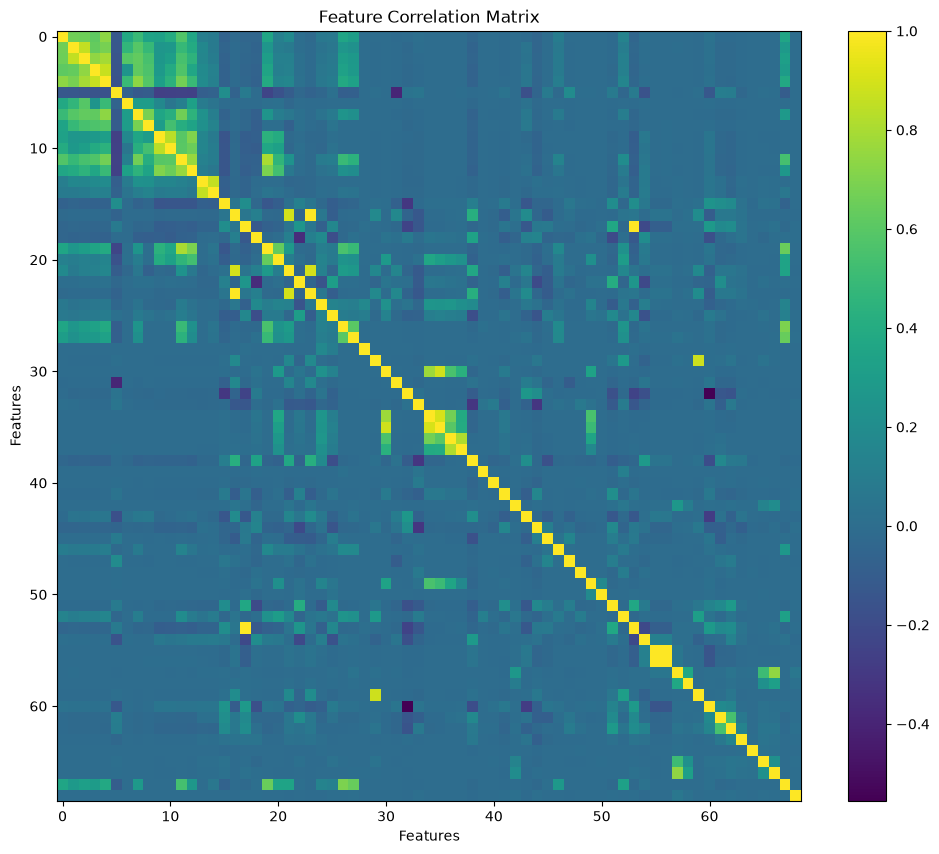

Top 15 positive correlated pairs:
 Machine                      Magic                          1.000
NumberOfSections             SectionsLength                 1.000
SectionMinRawsize            SectionMinVirtualsize          0.999
MajorOperatingSystemVersion  MinorOperatingSystemVersion    0.903
SizeOfOptionalHeader         Magic                          0.901
Machine                      SizeOfOptionalHeader           0.901
BaseOfCode                   MinorOperatingSystemVersion    0.886
AddressOfEntryPoint          SectionMaxPointerData          0.883
e_cparhdr                    e_minalloc                     0.867
e_oemid                      e_oeminfo                      0.857
e_cp                         e_crlc                         0.856
e_ip                         e_cs                           0.837
MajorImageVersion            MinorImageVersion              0.814
e_lfarlc                     PointerToSymbolTable           0.802
e_crlc                       e_minalloc  

In [19]:
Xn = X.drop(columns=constant_features)
corr = Xn.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto"); plt.colorbar()
plt.title("Feature Correlation Matrix"); plt.xlabel("Features"); plt.ylabel("Features")
plt.show()

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
              .stack().sort_values(ascending=False))
print("Top 15 positive correlated pairs:\n", corr_pairs.head(15).round(3).to_string())
print("\nTop 15 negative correlated pairs:\n", corr_pairs.sort_values().head(15).round(3).to_string())

## Task 7 — Outlier Investigation (IQR)

In [20]:
for f in features:
    q1, q3 = X[f].quantile(.25), X[f].quantile(.75); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((X[f] < lo) | (X[f] > hi)).sum()
    print(f"{f}: {n} outliers ({100*n/len(X):.1f}%)")

SizeOfCode: 2308 outliers (11.8%)
SizeOfImage: 1759 outliers (9.0%)
NumberOfSections: 249 outliers (1.3%)
SizeOfHeaders: 4841 outliers (24.7%)
SizeOfInitializedData: 1281 outliers (6.5%)


## Task 8 — Standardized Class Difference

In [21]:
mean_m, mean_b = malware[Xn.columns].mean(), benign[Xn.columns].mean()
std_m,  std_b  = malware[Xn.columns].std(),  benign[Xn.columns].std()
effect = (abs(mean_m - mean_b) / np.sqrt((std_m**2 + std_b**2) / 2))
effect = effect.replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
print("Top 15 by standardized difference:\n", effect.head(15).round(3).to_string())

Top 15 by standardized difference:
 MajorSubsystemVersion        1.584
Subsystem                    1.059
SectionMaxChar               0.819
SizeOfStackReserve           0.707
Magic                        0.598
Machine                      0.598
TimeDateStamp                0.563
SuspiciousImportFunctions    0.563
SizeOfOptionalHeader         0.554
FileAlignment                0.476
DllCharacteristics           0.464
MinorLinkerVersion           0.409
SectionAlignment             0.397
CheckSum                     0.382
MajorLinkerVersion           0.372


## Task 9 — Feature Relationships

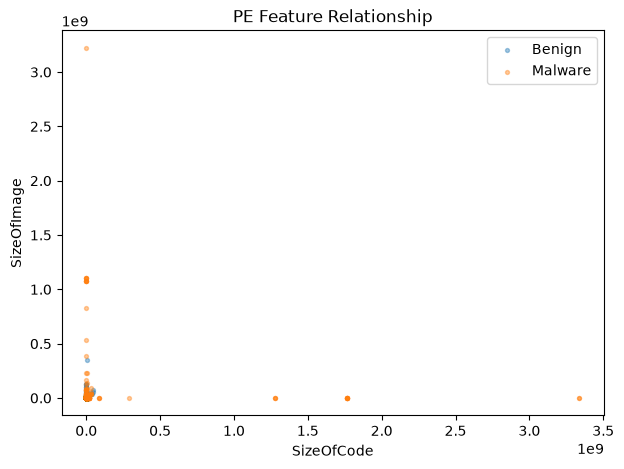

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(benign["SizeOfCode"], benign["SizeOfImage"], alpha=0.4, label="Benign", s=8)
plt.scatter(malware["SizeOfCode"], malware["SizeOfImage"], alpha=0.4, label="Malware", s=8)
plt.xlabel("SizeOfCode"); plt.ylabel("SizeOfImage")
plt.title("PE Feature Relationship"); plt.legend(); plt.show()